# Remote-Photoplethysmography (RPPG) and Respiration Signal Processing 
Created by : Dinda Joycehana_122140048

#### Imports and Dependencies

In [42]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

#### Setup MediaPipe Models 

In [43]:
# Face Detector
base_model = "models/blaze_face_short_range.tflite"
base_options = python.BaseOptions(model_asset_path=base_model)
FaceDetectorOptions = vision.FaceDetectorOptions
VisionRunningMode = vision.RunningMode
face_options = FaceDetectorOptions(
    base_options=base_options,
    running_mode=VisionRunningMode.IMAGE,
)
face_detector = vision.FaceDetector.create_from_options(face_options)

# Pose Landmarker
model_path = "models/pose_landmarker.task"
BaseOptions = mp.tasks.BaseOptions
PoseLandmarkerOptions = vision.PoseLandmarkerOptions

pose_options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False
)
pose_landmarker = vision.PoseLandmarker.create_from_options(pose_options)


#### rPPG : POS Function 

In [44]:
def POS(signal, **kwargs):
    eps = 10**-9
    X = signal
    e, c, f = X.shape
    w = int(1.6 * kwargs['fps'])
    
    P = np.array([[0, 1, -1], [-2, 1, 1]])
    Q = np.stack([P for _ in range(e)], axis=0)
    
    H = np.zeros((e, f))
    for n in np.arange(w, f):
        m = n - w + 1
        
        Cn = X[:, :, m:(n+1)]
        M = 1.0 / (np.mean(Cn, axis=2) + eps)
        M = np.expand_dims(M, axis=2)
        Cn = np.multiply(Cn, M)
        
        S = np.dot(Q, Cn)
        S = S[0, :, :, :]
        S = np.swapaxes(S, 0, 1)
        
        S1 = S[:, 0, :]
        S2 = S[:, 1, :]
        alpha = np.std(S1, axis=1) / (eps + np.std(S2, axis=1))
        alpha = np.expand_dims(alpha, axis=1)
        Hn = np.add(S1, alpha * S2)
        Hnm = Hn - np.expand_dims(np.mean(Hn, axis=1), axis=1)
        
        H[:, m:(n + 1)] = np.add(H[:, m:(n + 1)], Hnm)
    
    return H


#### Filter Functions 

In [45]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs # Nyquist frequency
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

#### Main Processing 

In [46]:
def run_rppg_respiration_analysis():
    # Initialize parameters
    fps = 15 # Frames per second
    time_window = 20 # Time window in seconds
    frames = time_window * fps # Total number of frames to capture
    count = 0 # Frame counter
    
    # Face detection parameters
    margin_x = 10 # Margin for face bounding box
    scaling_factor = 0.8 # Scaling factor for face bounding box
    
    # Data storage
    r_signal, g_signal, b_signal = [], [], [] # save RGB signals values
    shoulder_y_positions = [] # save shoulder Y positions for respiration analysis
    
    # Start webcam
    cap = cv2.VideoCapture(0)
    
    try:
        while count < frames: #check if we have captured enough frames
            ret, frame = cap.read() #read frame from webcam
            if not ret:
                print("Error: Failed to capture video") # exit loop if no frame is captured
                break
            
            # Convert to RGB for MediaPipe
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_height, frame_width, _ = rgb_frame.shape
            
            # Create MediaPipe Image
            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=rgb_frame
            )
            
            # Face Detection for rPPG 
            face_results = face_detector.detect(mp_image) # initialize face detection
            face_detected = False # first assume no face detected
            
            if face_results.detections:
                for detection in face_results.detections:
                    # Get bounding box
                    bboxC = detection.bounding_box # bounding box coordinates
                    x, y, w, h = bboxC.origin_x, bboxC.origin_y, bboxC.width, bboxC.height
                    
                    # Adjust bounding box
                    new_x = int(x + margin_x)
                    new_y = int(y)
                    new_w = int(w * scaling_factor)
                    new_h = int(h * scaling_factor)
                    
                    # Prevent out of bounds
                    new_x = max(0, min(new_x, frame_width - 1))
                    new_y = max(0, min(new_y, frame_height - 1))
                    new_w = min(new_w, frame_width - new_x)
                    new_h = min(new_h, frame_height - new_y)
                    
                    # Extract face ROI
                    face_roi = rgb_frame[new_y:new_y+new_h, new_x:new_x+new_w]
                    
                    if face_roi.size > 0:
                        # Calculate mean RGB values
                        mean_rgb = cv2.mean(face_roi)[:3]
                        r_signal.append(mean_rgb[0])
                        g_signal.append(mean_rgb[1])
                        b_signal.append(mean_rgb[2])
                        face_detected = True
                        
                        # Draw face bounding box
                        cv2.rectangle(frame, (new_x, new_y), 
                                    (new_x + new_w, new_y + new_h), (0, 255, 0), 2)
                    break
            
            # If no face detected, append zeros to maintain alignment
            if not face_detected:
                r_signal.append(0)
                g_signal.append(0)
                b_signal.append(0)
            
            # Pose Detection for Respiration 
            pose_result = pose_landmarker.detect(mp_image) # initialize pose detection
            pose_detected = False # first assume no pose detected
            
            if pose_result.pose_landmarks:
                landmarks = pose_result.pose_landmarks[0] # Get first detected pose landmarks
                
                # Get shoulder landmarks
                left_shoulder = landmarks[11]  # Left shoulder
                right_shoulder = landmarks[12]  # Right shoulder
                
                # Calculate average shoulder Y position
                avg_shoulder_y = (left_shoulder.y + right_shoulder.y) / 2 # Average Y position of shoulders
                shoulder_y_positions.append(avg_shoulder_y) # save shoulder Y position
                pose_detected = True # pose detected
                
                # Draw shoulder points and chest ROI
                left_x_px = int(left_shoulder.x * frame_width) 
                left_y_px = int(left_shoulder.y * frame_height)
                right_x_px = int(right_shoulder.x * frame_width)
                right_y_px = int(right_shoulder.y * frame_height)
                
                cv2.circle(frame, (left_x_px, left_y_px), 5, (255, 0, 0), -1)
                cv2.circle(frame, (right_x_px, right_y_px), 5, (255, 0, 0), -1)
                
                # Draw chest ROI
                center_x = int((left_shoulder.x + right_shoulder.x) * frame_width / 2)
                center_y = int((left_shoulder.y + right_shoulder.y) * frame_height / 2)
                roi_left = max(0, center_x - 140)
                roi_right = min(frame_width, center_x + 140)
                roi_top = max(0, center_y - 80)
                roi_bottom = min(frame_height, center_y)
                
                cv2.rectangle(frame, (roi_left, roi_top), 
                            (roi_right, roi_bottom), (0, 0, 255), 2)
            
            # If no pose detected, append zero to maintain alignment
            if not pose_detected:
                shoulder_y_positions.append(0) 
            
            # Display frame
            cv2.putText(frame, f"Frame: {count}/{frames}", (10, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.putText(time_window, f"Time: {count / fps:.2f}s", (10, 60), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.imshow('rPPG + Respiration Analysis', frame)
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            
            count += 1
    
    finally:
        cap.release()
        cv2.destroyAllWindows()
    
    return r_signal, g_signal, b_signal, shoulder_y_positions


In [ ]:
# Signal Processing and Analysis 
def analyze_signals(r_signal, g_signal, b_signal, shoulder_y_positions, fps=15):
    # Convert to numpy arrays
    r_signal = np.array(r_signal)
    g_signal = np.array(g_signal)
    b_signal = np.array(b_signal)
    shoulder_y_positions = np.array(shoulder_y_positions)
    
    # Remove zero values (frames where detection failed)
    valid_face_indices = (r_signal != 0) & (g_signal != 0) & (b_signal != 0)
    valid_pose_indices = shoulder_y_positions != 0
    
    results = {}
    
    # rPPG Analysis 
    if np.sum(valid_face_indices) > fps * 10:  # At least 10 seconds of data
        # Use POS method
        rgb_signals = np.array([r_signal[valid_face_indices], 
                               g_signal[valid_face_indices], 
                               b_signal[valid_face_indices]])
        rgb_signals = rgb_signals.reshape(1, 3, -1)
        
        rppg_signal = POS(rgb_signals, fps=fps)
        rppg_signal = rppg_signal.reshape(-1)
        
        # Filter for heart rate (0.7-2.5 Hz)
        if len(rppg_signal) > fps * 5: # At least 5 seconds of data
            filtered_rppg = bandpass_filter(rppg_signal, 0.7, 2.5, fps) # Bandpass filter for heart rate
            rppg_peaks, _ = find_peaks(filtered_rppg, distance=int(fps/4)) # Minimum distance between 
            time_rppg = np.arange(len(filtered_rppg)) / fps
            
            if len(rppg_peaks) > 1:
                heart_rate = len(rppg_peaks) * 60 / time_rppg[-1]
                results['rppg'] = {
                    'signal': filtered_rppg,
                    'peaks': rppg_peaks,
                    'time': time_rppg,
                    'heart_rate': heart_rate
                }
    
    # Respiration Analysis
    if np.sum(valid_pose_indices) > fps * 10:  # At least 10 seconds of data
        valid_shoulder_y = shoulder_y_positions[valid_pose_indices] #
        
        # Filter for respiration (0.1-0.5 Hz)
        if len(valid_shoulder_y) > fps * 5: # At least 5 seconds of data
            filtered_resp = bandpass_filter(valid_shoulder_y, 0.1, 0.5, fps) # Bandpass filter for respiration
            resp_peaks, _ = find_peaks(filtered_resp, distance=int(fps/2)) # Minimum distance between peaks
            time_resp = np.arange(len(filtered_resp)) / fps  
            
            if len(resp_peaks) > 1:
                resp_rate = len(resp_peaks) * 60 / time_resp[-1]
                results['respiration'] = { 
                    'signal': filtered_resp,
                    'peaks': resp_peaks,
                    'time': time_resp,
                    'resp_rate': resp_rate
                }
    
    return results


#### Visualization 

In [ ]:
def plot_results(results):
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot rPPG
    if 'rppg' in results:
        rppg_data = results['rppg']
        axes[0].plot(rppg_data['time'], rppg_data['signal'], 'b-', label='Filtered rPPG')
        axes[0].plot(rppg_data['time'][rppg_data['peaks']], rppg_data['signal'][rppg_data['peaks']], 'ro', label='Peaks')
        axes[0].set_title(f'rPPG Signal (Heart Rate: {rppg_data["heart_rate"]:.1f} BPM)')
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Amplitude')
        axes[0].legend()
        axes[0].grid(True)
    else:
        axes[0].set_title('No valid rPPG data')
        axes[0].text(0.5, 0.5, 'Insufficient face detection data', ha='center', va='center', transform=axes[0].transAxes)
    
    # Plot Respiration
    if 'respiration' in results:
        resp_data = results['respiration']
        axes[1].plot(resp_data['time'], resp_data['signal'], 'g-', label='Filtered Respiration')
        axes[1].plot(resp_data['time'][resp_data['peaks']], resp_data['signal'][resp_data['peaks']], 'ro', label='Peaks')
        axes[1].set_title(f'Respiration Signal (Rate: {resp_data["resp_rate"]:.1f} breaths/min)')
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('Shoulder Y Position')
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].set_title('No valid respiration data')
        axes[1].text(0.5, 0.5, 'Insufficient pose detection data', ha='center', va='center', transform=axes[1].transAxes)
    
    plt.tight_layout()
    plt.show()


#### Main Execution

Starting rPPG and Respiration Analysis...
Press 'q' to quit early
Collected 300 frames of data
Processing signals...
Heart Rate: 150.5 BPM
Respiration Rate: 21.1 breaths/min


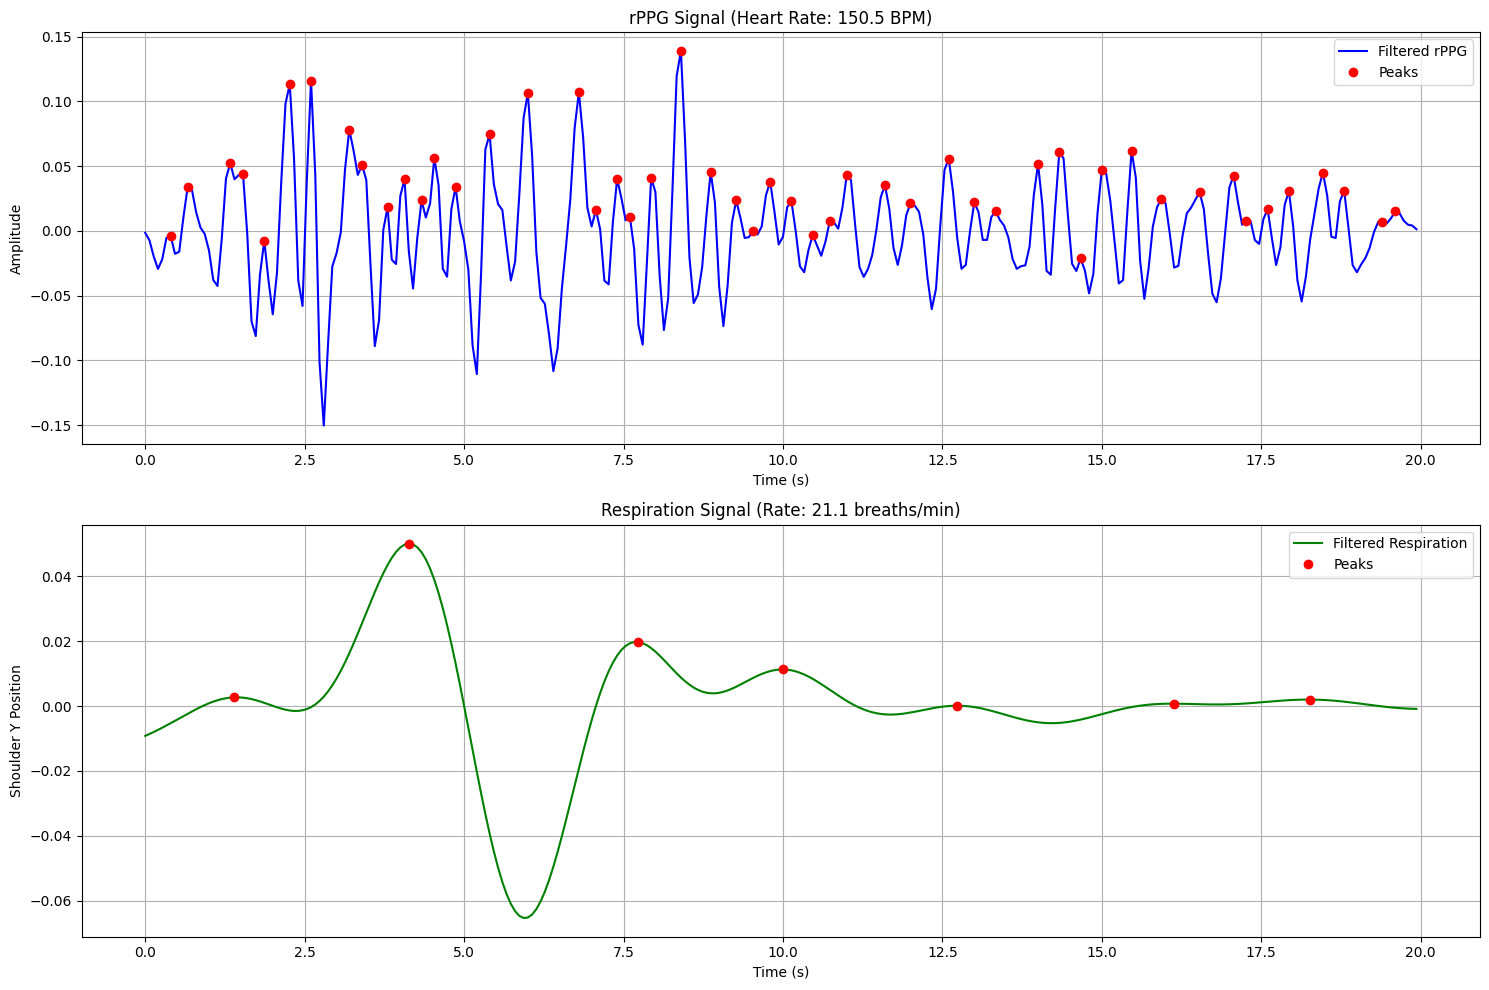

In [49]:
if __name__ == "__main__":
    print("Starting rPPG and Respiration Analysis...")
    print("Press 'q' to quit early")
    
    # Collect data
    r_sig, g_sig, b_sig, shoulder_y = run_rppg_respiration_analysis()
    
    print(f"Collected {len(r_sig)} frames of data")
    print("Processing signals...")
    
    # Analyze signals
    results = analyze_signals(r_sig, g_sig, b_sig, shoulder_y)
    
    # Display results
    if 'rppg' in results:
        print(f"Heart Rate: {results['rppg']['heart_rate']:.1f} BPM")
    else:
        print("Could not calculate heart rate - insufficient face detection")
    
    if 'respiration' in results:
        print(f"Respiration Rate: {results['respiration']['resp_rate']:.1f} breaths/min")
    else:
        print("Could not calculate respiration rate - insufficient pose detection")
    
    # Plot results
    plot_results(results)